# Load packages

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from functions import *
import timeit
import torch
from model import MultiAttModel
import esm

# Load model

In [2]:
# path to model weights
topt_pth = '../../large_model_pth/model_topt_window=3_r2=0.539321.pth';
# define device
device = torch.device('cpu')
emb_dim= 320; window=3; n_head = 4; n_RD = 4;
model = MultiAttModel( emb_dim, window, n_head, n_RD)
model.to(device);
model.load_state_dict(torch.load( topt_pth, map_location=device  ));
model.eval();

# Load ESM-2

In [3]:
esm2_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D() # 6 layers
esm2_model = esm2_model.to(device)
esm2_batch_converter = alphabet.get_batch_converter()

# Example

In [8]:
topt_data = pd.read_csv('../data/Topt/sequence_ogt_topt.csv')
example_seq = topt_data['sequence'][0]
print(example_seq)
print(len(example_seq))

MKNKVVVVTGVPGVGGTTLTQKTIEKLKEEGIEYKMVNFGTVMFEVAKEEGLVEDRDQMRKLDPDTQKRIQKLAGRKIAEMAKESNVIVDTHSTVKTPKGYLAGLPIWVLEELNPDIIVIVETSSDEILMRRLGDATRNRDIELTSDIDEHQFMNRCAAMAYGVLTGATVKIIKNRDGLLDKAVEELISVLK
192


In [9]:
def predict(seq):
    inputs = [('Temp', seq)] 
    batch_labels, batch_strs, batch_tokens = esm2_batch_converter(inputs)
    batch_tokens = batch_tokens.to(device=device, non_blocking=True)
    with torch.no_grad():
        emb = esm2_model(batch_tokens, repr_layers=[6], return_contacts=False)
    emb = emb["representations"][6]
    emb = emb.transpose(1,2)
    emb = emb.to(device)
    with torch.no_grad():
        preds = model( emb )
    return preds

In [10]:
Topt_max=120
print(predict(example_seq)*Topt_max)

tensor([[57.3689]])


# Runtime of different sequence lengths

In [14]:
factors = np.arange(1,16)
runtimes = []
for factor in factors:
    start = timeit.default_timer()
    pred = predict(example_seq*factor)
    stop = timeit.default_timer()
    runtimes.append(stop-start)

(0.0, 5.0)

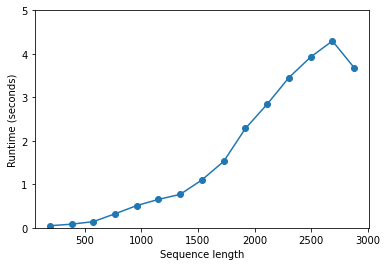

In [16]:
plt.plot( [len(example_seq)*f for f in factors], runtimes, marker='o')
plt.xlabel('Sequence length')
plt.ylabel('Runtime (seconds)')
plt.ylim([0,5])